In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
rng = np.random.default_rng()

# Co to są przedziały ufności i dlaczego są ważne

## Scenariusz

Wyobraź sobie, że prowadzisz badanie, w którym chcesz sprawdzić, czy dzieci urodzone przez kobiety, które korzystały w ciąży z papierosów elektronicznych ważą mniej, niż noworodki w ogólnej populacji. 

*Uwaga: Dane w omawianym przykładzie nie są prawdziwe, mają jedynie walor ilustracyjny! Ponadto, należałoby założyć, że średnie wagi urodzeniowe dziewczynek i chłopców nieco się różnią. *

Załóżmy, że wiemy, że waga urodzeniowa noworodków w ogólnej populacji ma rozkład normalny o średniej 3.2 kg i odchyleniu standardowym 0.5 kg. Rozkład ten wygląda tak:

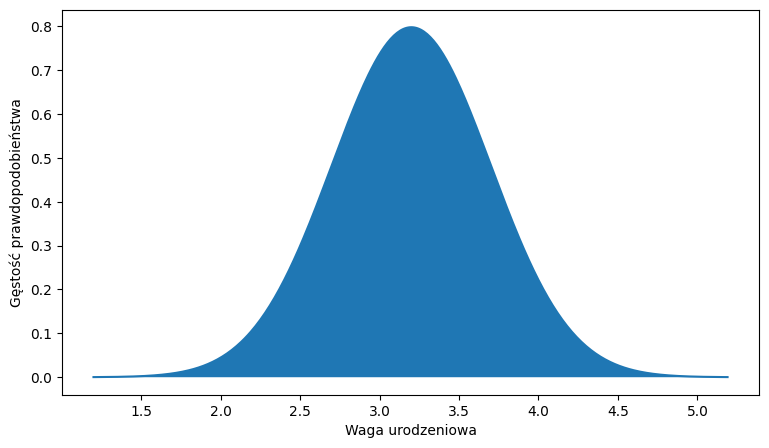

In [2]:
sd = 0.5
mean = 3.2

x = np.arange(1.2, 5.2, 0.01)
y = norm.pdf(x, loc=mean, scale=sd)
fix, ax = plt.subplots(figsize=(9, 5))
ax.plot(x,y)
ax.fill_between(x, y)
ax.set_xlabel("Waga urodzeniowa")
ax.set_ylabel("Gęstość prawdopodobieństwa")
plt.show()

Jeżeli chcesz sprawdzić, jak zmienia się kształt rozkładu normalnego, gdy zmieniają się średnia (mean) i odchylenie 
standardowe (sd), użyj suwaków poniżej.

In [3]:
@interact(mean=(1.0,5.0), sd=(0.1,1.0))
def norm_plot(mean=3.2, sd=0.5):
    x = np.arange(1, 6, 0.01)
    y = norm.pdf(x, loc=mean, scale=sd)
    fix, ax = plt.subplots(figsize=(9, 5))
    ax.plot(x,y)
    ax.fill_between(x, y)
    ax.set_xlim((1, 6))
    ax.set_ylim((0, 1.5))
    ax.set_xlabel("Waga urodzeniowa")
    ax.set_ylabel("Gęstość prawdopodobieństwa")
    plt.show()

interactive(children=(FloatSlider(value=3.2, description='mean', max=5.0, min=1.0), FloatSlider(value=0.5, des…

## Symulujemy badania!

Kiedy prowadzimy badania, nie znamy parametrów rozkładu w interesującej nas populacji - badania prowadzimy właśnie po to, by je poznać, np. dowiedzieć się, jaka jest średnia waga urodzeniowa w populacji dzieci matek, które używały w ciąży elektronicznych papierosów.

Na potrzeby niniejszej prezentacji Statystyczny Potwór Spaghetti, który zna parametry wszystkich rozkładów we 
Wszechświecie, wyjawił mi jednak, jakie są parametry rozkładu wagi urodzeniowej dzieci matek, które w ciąży używały elektronicznych papierosów. Dzięki temu możemy zasymulować losowanie próby 100 noworodków. Wielokrotnie!

Wciśnij przycisk "losuj", aby wylosować próbę 100 dzieci matek, które używały papierosów elektronicznych w ciąży i przedstawić rozkład ich wagi urodzeniowej na histogramie. **Wciśnij przycisk więcej niż raz, najlepiej co najmniej 10 razy**, żeby zobaczyć, jak bardzo będą różnić się rozkłady w kolejnych badaniach! Czerwona pionowa linia oznacza uzyskaną w próbie średnią.

In [13]:
from IPython.display import display

button = widgets.Button(
    value=False,
    description='Losuj próbę!',
    disabled=False,
    button_style='', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Wciśnij przycisk, żeby wylosować próbę 100 dzieci i przedstawić ich wagę urodzeniową na histogramie!'
)

output = widgets.Output()
display(button, output)

true_mean=3.0
sample_size=100

def sample_and_plot(b, rng=rng):
    sample = rng.normal(loc=true_mean, scale=0.5, size=sample_size)
    with output:
        fig, ax = plt.subplots(figsize=(4,3))
        ax.hist(sample)
        ax.vlines(x=np.mean(sample), ymin=0, ymax=1, transform=ax.get_xaxis_transform(), color="red")
        ax.set_xlim((1.5,4.5))
        ax.set_xlabel("Waga urodzeniowa")
        ax.set_ylabel("Liczba obserwacji")
        plt.show()
    
button.on_click(sample_and_plot)

Button(description='Losuj próbę!', style=ButtonStyle(), tooltip='Wciśnij przycisk, żeby wylosować próbę 100 dz…

Output()

## Błąd standardowy średniej

Jeżeli wylosowałaś/eś więcej niż jedną próbę, widzisz, że dla każdej wylosowanej próby otrzymujemy nieco inną średnią! Jak bardzo średnie te mogą się różnić? I czy któraś z nich to ta prawdziwa średnia z interesującej nas populacji? Wyobraźcie sobie, że podobne badanie zrealizujemy wiele razy, za każdym razem obliczamy średnią i nanosimy ją na wykres. Jedna kropka to jedno badanie. Użyj suwaka, aby zmienić liczbę badań. Czerwona pionowa linia oznacza średnią uzyskaną na podstawie wszystkich widocznych na wykresie badań.

*Zwróć uwagę, że kiedy dodajesz badania, zmienia się skala osi y, przedstawiającej liczbę badań.*

*Pewnie będzie trzeba chwilkę poczekać na aktualizację wykresu po przesunięciu suwaka.*

In [68]:
samples = rng.normal(loc=true_mean, scale=sd, size=sample_size*10000).reshape((10000,sample_size))

def pointplot(ax, data, true_mean, sem):
    bins = np.linspace(true_mean-4*sem, true_mean+4*sem, 31)
    means = np.sort(np.mean(data, axis=1))
    n_samples = data.shape[0]
    ax.set_xlim((true_mean-4*sem, true_mean+4*sem))
    ax.set_xlabel("Średnia")
    ax.set_ylabel("Liczba badań")
    ax.vlines(x=np.mean(means), ymin=0, ymax=1, transform=ax.get_xaxis_transform(), color="red")
    extremely_small=np.sum(means < bins[0])
    extremely_big=np.sum(means>=bins[-1])
    current_bin=1
    counter=1
    for m in means[extremely_small:n_samples-extremely_big]:
        if m < bins[current_bin]:
            x = (bins[current_bin-1]+bins[current_bin])/2
            ax.plot(x, counter, 'bo', alpha=0.3)
            counter+=1
        elif m >= bins[current_bin]:
            current_bin = np.sum(bins < m)
            counter=1
            x = (bins[current_bin-1]+bins[current_bin])/2
            ax.plot(x, counter, 'bo', alpha=0.3)
            counter+=1
        else:
            print("Pojawił się niespodziewany błąd, spróbuj jeszcze raz")

def plot_many_samples(n=100):
    fig, ax = plt.subplots(figsize=(9,5))
    sem = sd/np.sqrt(sample_size)
    pointplot(ax, samples[:n], true_mean, sem)
    plt.show()

interact(plot_many_samples, n=widgets.IntSlider(100, 100, 10000, 100, layout=widgets.Layout(width='500px')))

interactive(children=(IntSlider(value=100, description='n', layout=Layout(width='500px'), max=10000, min=100, …

<function __main__.plot_many_samples(n=100)>

Patrząc na powyższy wykres (i ruszając suwakiem!) warto zwrócić uwagę na dwie rzeczy: 

1. Skala osi x jest krótsza, niż w przypadku histogramów przedstawiajcych wagi pojedynczych noworodków w jednym badaniu (od 2.8 do 3.2, a nie od 1.5 do 4.5). 
2. Średnia obliczona na podstawie wszystkich przeprowadzonych badań dąży do wartości 3. Dla kilkuset badań nieco waha się, kiedy dodajemy badania, ale od pewnego momentu pozostaje w jednym miejscu.
2. Szerokość naszego rozkładu jest względnie stała, pojawiają się pojedyncze obserwacje na krańcach rozkładu, ale zdecydowana większość obserwacji mieści się w ustalonym przedziale poniżej i powyżej wartości 3.
2. Rozkład średnich jest zbliżony do rozkładu normalnego! Im więcej średnich, tym bardziej jest to widoczne. 

Na wykresie poniżej widzisz rozkład średnich z 10 000 badań (tym razem w formie zwykłego histogramu, bez kropek oznaczajcych pojedyncze badania), porównany z rozkładem normalnym o średniej 3 i odchyleniu standardowym, które możemy określić obliczając tzw. **błąd standardowy średniej**, oznaczony na wykresie poziomymi strzałkami.

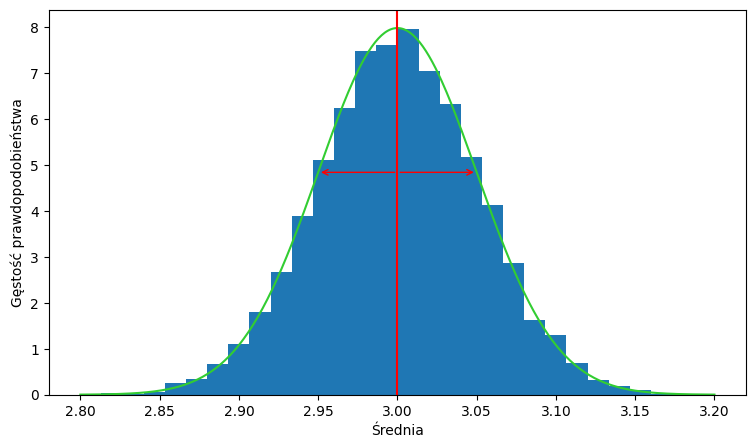

In [71]:
sem = sd/np.sqrt(sample_size)
fig, ax = plt.subplots(figsize=(9,5))
ax.hist(np.mean(samples, axis=1), bins=np.linspace(true_mean-4*sem, true_mean+4*sem, 31)[1:], density=True)
ax.set_ylabel("Gęstość prawdopodobieństwa")
ax.set_xlabel("Średnia")
x=np.arange(2.8, 3.2, 0.001)
ax.plot(x, norm.pdf(x, loc=3, scale=sem), color="limegreen")
ax.vlines(x=3, ymin=0, ymax=1, transform=ax.get_xaxis_transform(), color="red")
sd_arrow_vertical=norm.pdf(3-sem, loc=3, scale=sem)
ax.annotate("", xytext=(3.0, sd_arrow_vertical), xy=(3-sem, sd_arrow_vertical),
            arrowprops=dict(arrowstyle="->", color="red"))
ax.annotate("", xytext=(3.0, sd_arrow_vertical), xy=(3+sem, sd_arrow_vertical),
            arrowprops=dict(arrowstyle="->", color="red"))
plt.show()

Błąd standardowy średniej to odchylenie standardowe średnich, jakie uzyskalibyśmy powtarzając nasze badanie wiele razy tak, jak w przykładzie powyżej. Oblicza się go tak:

$$SEM = \frac{s}{\sqrt{n}},$$

gdzie $n$ to liczebność próby w pojedynczym badaniu, a $s$ to odchylenie standardowe w badanej populacji.

Zobaczmy zatem, jak będzie wyglądał rozkład naszych średnich, jeżeli zmniejszymy lub zwiększymy próbę w naszym badaniu. Zwróć uwagę na to, że kiedy ruszasz suwakiem, zmienia się skala osi y. To dlatego, że pole pod wykresem zawsze wynosi 1 (wrócimy do tego zaraz), więc im węższy wykres, tym wyżej musi sięgać.

In [77]:
@interact(n=(10,1000,10))
def SEM_compare(n=100):
    sem = sd/np.sqrt(n)
    x=np.arange(2.8, 3.2, 0.001)
    fig, ax = plt.subplots(figsize=(9,5))
    ax.set_ylabel("Gęstość prawdopodobieństwa")
    ax.set_xlabel("Średnia")
    ax.set_xlim((2.8, 3.2))
    ax.plot(x, norm.pdf(x, loc=3, scale=sem), color="black")
    plt.show()

interactive(children=(IntSlider(value=100, description='n', max=1000, min=10, step=10), Output()), _dom_classe…